# Notebook 07 — Generate embeddings for all Lyon restaurants

For each of the 148 Lyon restaurants, we build a rich text representation
(name + cuisine + vibes + signatures + description) and generate a 512-dim
embedding using Voyage AI's `voyage-3-lite` model.

These embeddings will power the semantic `recommend_by_vibe` tool: at query
time, we embed the user's request and find the restaurants closest in vector
space.

We also visualize the embeddings in 2D with UMAP to verify they cluster by
restaurant "feel" — restaurants with similar vibes should sit near each other.

**Output**: `data/embeddings.json` — restaurants with their embeddings, ready
to be ingested by Chroma in the next notebook.

**Cost**: ~0.0005 USD (148 short texts on Voyage's free tier).

In [1]:
"""Notebook 07 — Generate embeddings for all Lyon restaurants."""

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import voyageai
from dotenv import load_dotenv
from tqdm import tqdm

# Setup
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

DATA_DIR = PROJECT_ROOT / "data"
RESTAURANTS_FILE = DATA_DIR / "lyon-restaurants.json"
EMBEDDINGS_FILE = DATA_DIR / "lyon-embeddings.json"

# Voyage client
vo = voyageai.Client()
MODEL = "voyage-3-lite"

print(f"Voyage API key loaded: {bool(os.environ.get('VOYAGE_API_KEY'))}")
print(f"Input file: {RESTAURANTS_FILE}")
print(f"Output file: {EMBEDDINGS_FILE}")

Voyage API key loaded: True
Input file: C:\Users\busar\Desktop\Projets\connoisseur\data\lyon-restaurants.json
Output file: C:\Users\busar\Desktop\Projets\connoisseur\data\lyon-embeddings.json


In [2]:
with open(RESTAURANTS_FILE, "r", encoding="utf-8") as f:
    restaurants = json.load(f)

print(f"Loaded {len(restaurants)} restaurants")
print(f"\nSample restaurant:")
print(json.dumps(restaurants[0], indent=2, ensure_ascii=False)[:500] + "...")

Loaded 148 restaurants

Sample restaurant:
{
  "name": "Lyon-Dakar",
  "location": "227 rue de Crequi, 69003 Lyon France",
  "type": "African",
  "food_style": "African",
  "rating": 4.0,
  "price_range": "€€-€€€",
  "signatures": [
    "Thiéboudienne (Senegalese fish and rice)",
    "Grilled lamb with sauce d'arachide",
    "Mafé (groundnut stew)"
  ],
  "vibe": [
    "convivial",
    "casual",
    "vibrant",
    "unpretentious",
    "neighbourhood-focused"
  ],
  "environment": "Lyon-Dakar brings authentic West African cooking to the C...


In [3]:
def build_restaurant_text(r: dict) -> str:
    """
    Build a rich text representation of a restaurant for embedding.
    
    The text combines structured fields (name, cuisine, price) with the
    descriptive enriched fields (vibes, signatures, environment) so the
    embedding captures both factual and atmospheric features.
    """
    parts = [
        f"Restaurant: {r['name']}.",
        f"Cuisine: {r.get('type', 'Unknown')}.",
        f"Location: {r.get('location', 'Lyon')}.",
        f"Price range: {r.get('price_range', '')}.",
    ]
    
    vibes = r.get("vibe", [])
    if vibes:
        parts.append(f"Atmosphere: {', '.join(vibes)}.")
    
    environment = r.get("environment", "")
    if environment:
        parts.append(f"Description: {environment}")
    
    signatures = r.get("signatures", [])
    if signatures:
        parts.append(f"Notable dishes: {', '.join(signatures)}.")
    
    shortcomings = r.get("shortcomings", [])
    if shortcomings:
        parts.append(f"Known shortcomings: {' '.join(shortcomings)}")
    
    return " ".join(parts)


# Preview the first 3
for r in restaurants[:3]:
    print(f"\n--- {r['name']} ---")
    print(build_restaurant_text(r))


--- Lyon-Dakar ---
Restaurant: Lyon-Dakar. Cuisine: African. Location: 227 rue de Crequi, 69003 Lyon France. Price range: €€-€€€. Atmosphere: convivial, casual, vibrant, unpretentious, neighbourhood-focused. Description: Lyon-Dakar brings authentic West African cooking to the Croix-Rousse neighbourhood, moving beyond the city's traditional Lyonnais repertoire with grilled meats, rich stews, and regional specialities prepared without nostalgia or irony. The restaurant occupies a straightforward dining space where the food speaks louder than decor, drawing a steady crowd of locals and curious eaters seeking genuine flavour over aesthetics. Notable dishes: Thiéboudienne (Senegalese fish and rice), Grilled lamb with sauce d'arachide, Mafé (groundnut stew). Known shortcomings: Service can be slow during peak hours, reflecting kitchen-focused priorities over table pacing Modest wine list tilts toward affordable reds and house selections; pairing options limited for adventurous diners

--- M

In [4]:
# Build all texts
texts = [build_restaurant_text(r) for r in restaurants]

print(f"Generating embeddings for {len(texts)} restaurants...")

# Voyage accepts batches. We can send all 40 in one call.
result = vo.embed(
    texts,
    model=MODEL,
    input_type="document",  # these are docs to be indexed
)

embeddings = result.embeddings
print(f"\n✅ Got {len(embeddings)} embeddings")
print(f"   Each vector has {len(embeddings[0])} dimensions")
print(f"   Total tokens used: {result.total_tokens}")
print(f"   Estimated cost: ${result.total_tokens / 1_000_000 * 0.02:.6f}")

Generating embeddings for 148 restaurants...

✅ Got 148 embeddings
   Each vector has 512 dimensions
   Total tokens used: 30062
   Estimated cost: $0.000601


In [5]:
# Build the output structure: each entry has the original restaurant data
# plus its embedding.
output = []
for restaurant, text, embedding in zip(restaurants, texts, embeddings):
    output.append({
        "itemId": restaurant["itemId"],
        "name": restaurant["name"],
        "embedding_text": text,           # the text we embedded
        "embedding": embedding,           # the 512-dim vector
        # Keep some metadata handy for filtering
        "type": restaurant.get("type"),
        "location": restaurant.get("location"),
        "price_range": restaurant.get("price_range"),
        "rating": restaurant.get("rating"),
        "vibe": restaurant.get("vibe", []),
    })

# Save to JSON
with open(EMBEDDINGS_FILE, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

size_kb = EMBEDDINGS_FILE.stat().st_size / 1024
print(f"✅ Saved {len(output)} embeddings to {EMBEDDINGS_FILE.name}")
print(f"   File size: {size_kb:.1f} KB")

✅ Saved 148 embeddings to lyon-embeddings.json
   File size: 2341.0 KB


In [6]:
import umap

# Convert embeddings to a numpy matrix
X = np.array(embeddings)  # shape: (40, 512)

print(f"Original shape: {X.shape}")

# UMAP: reduce 512 dims → 2 dims while preserving relative distances
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=8,          # how many neighbors UMAP considers for each point
    min_dist=0.3,           # how tight clusters can be
    random_state=42,        # for reproducibility
)

X_2d = reducer.fit_transform(X)
print(f"Reduced shape: {X_2d.shape}")

Original shape: (148, 512)


C:\Users\busar\Desktop\Projets\connoisseur\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (148, 2)


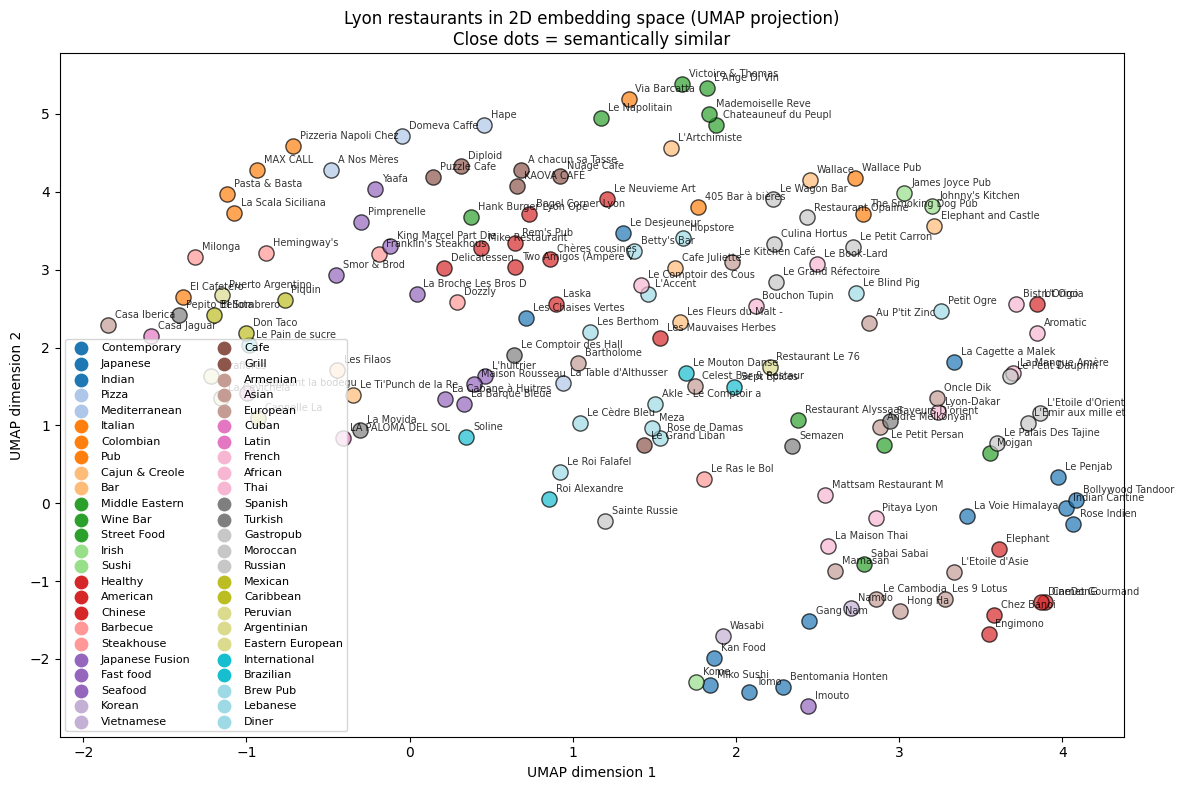


Saved figure to docs/embeddings_umap.png


In [7]:
plt.figure(figsize=(12, 8))

# Color by primary cuisine type
cuisines = [r.get("type", "Unknown") for r in restaurants]
unique_cuisines = list(set(cuisines))

# Assign a color per cuisine
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_cuisines)))
cuisine_to_color = {c: colors[i] for i, c in enumerate(unique_cuisines)}

# Plot each point
for i, r in enumerate(restaurants):
    color = cuisine_to_color[r.get("type", "Unknown")]
    plt.scatter(X_2d[i, 0], X_2d[i, 1], c=[color], s=120, alpha=0.7, edgecolors='black')
    plt.annotate(
        r["name"][:20],
        (X_2d[i, 0], X_2d[i, 1]),
        fontsize=7,
        alpha=0.8,
        xytext=(5, 5),
        textcoords='offset points',
    )

# Legend (one entry per cuisine)
for cuisine, color in cuisine_to_color.items():
    plt.scatter([], [], c=[color], label=cuisine, s=80)

plt.legend(loc='best', fontsize=8, ncol=2)
plt.title("Lyon restaurants in 2D embedding space (UMAP projection)\nClose dots = semantically similar")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "embeddings_umap.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\nSaved figure to docs/embeddings_umap.png")

In [8]:
def cosine_similarity_matrix(X):
    """Compute cosine similarity between every pair of rows in X."""
    X_normalized = X / np.linalg.norm(X, axis=1, keepdims=True)
    return X_normalized @ X_normalized.T


sim_matrix = cosine_similarity_matrix(X)

# Pick a random restaurant
target_idx = 0  # change this to explore different restaurants
target_name = restaurants[target_idx]["name"]

# Get similarities to all others, sorted desc
sims = sim_matrix[target_idx]
# Exclude self (which has similarity 1.0)
sorted_indices = np.argsort(sims)[::-1][1:6]  # top 5 excluding self

print(f"Top 5 restaurants most similar to: {target_name!r}")
print(f"(Type: {restaurants[target_idx].get('type')}, "
      f"Vibes: {restaurants[target_idx].get('vibe')})\n")

for rank, idx in enumerate(sorted_indices, 1):
    r = restaurants[idx]
    print(f"  {rank}. {r['name']} (similarity: {sims[idx]:.3f})")
    print(f"     Type: {r.get('type')}")
    print(f"     Vibes: {', '.join(r.get('vibe', []))}")
    print()

Top 5 restaurants most similar to: 'Lyon-Dakar'
(Type: African, Vibes: ['convivial', 'casual', 'vibrant', 'unpretentious', 'neighbourhood-focused'])

  1. La Mangue Amère (similarity: 0.723)
     Type: African
     Vibes: intimate, convivial, understated, authentically modest

  2. Le Petit Dauphin (similarity: 0.701)
     Type: Moroccan
     Vibes: warm-spiced, intimate, convivial, neighborhood-focused

  3. La Barque Bleue (similarity: 0.682)
     Type: Seafood
     Vibes: casual-nautical, neighborhood-focused, unpretentious, lively

  4. Oncle Dik (similarity: 0.675)
     Type: Armenian
     Vibes: convivial, unpretentious, eclectic, neighborhood-focused

  5. DineDonG (similarity: 0.673)
     Type: Chinese
     Vibes: casual-contemporary, buzzing, unpretentious, family-friendly, efficient

